In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
energy_df=pd.read_csv("/content/energy_data.csv")
energy_df

,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153
...,...,...,...,...
9995,21-02-2024 11:00,Industrial,437.468420,31.507440
9996,21-02-2024 12:00,Residential,147.061116,18.629344
9997,21-02-2024 13:00,Commercial,129.039725,24.528343
9998,21-02-2024 14:00,Commercial,164.020368,33.986510


In [ ]:
energy_df.head()

,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153


In [ ]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           10000 non-null  object 
 1   location            10000 non-null  object 
 2   energy_consumption  10000 non-null  float64
 3   temperature         10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [ ]:
energy_df.shape

(10000, 4)

In [ ]:
energy_df.isnull().sum()

,0
timestamp,0
location,0
energy_consumption,0
temperature,0


In [ ]:
X=energy_df[['energy_consumption','temperature']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_scaled

array([[-1.0542926 ,  1.52684411],
       [-0.21885876,  0.24236751],
       [-0.32076688,  0.0062966 ],
       ...,
       [-1.13211831, -0.08000961],
       [-0.86154675,  1.55554414],
       [ 1.359738  ,  0.28751874]])

In [ ]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
energy_df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, energy_df['cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.37


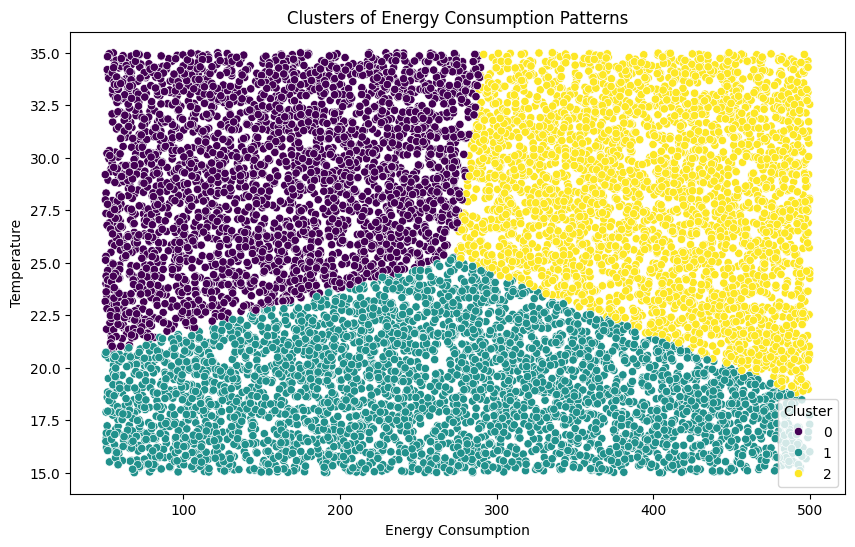

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='energy_consumption',
    y='temperature',
    hue='cluster',
    data=energy_df,
    palette='viridis'
)

plt.title('Clusters of Energy Consumption Patterns')
plt.xlabel('Energy Consumption')
plt.ylabel('Temperature')
plt.legend(title='Cluster')

plt.show()

In [ ]:
# TODAY Task

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/API_EN.ATM.CO2E.PC_DS57_en_csv_v2_2822.csv",
    skiprows=4
)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2660.110136,2714.756817,2939.390272,2792.344200,2699.048789,2407.690195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andorra,AND,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Africa Eastern and Southern,AFE,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,4.530298,4.612370,4.654079,4.702848,4.980167,5.236399,...,17.892214,17.532203,11.860916,6.363359,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,4.470474,5.195537,7.141315,7.187699,8.349586,9.816883,...,4.135320,4.416434,3.182961,1.787831,NaN,NaN,NaN,NaN,NaN,NaN
4,Africa Western and Central,AFW,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,0.454398,0.476414,0.483062,0.561880,0.666292,0.924014,...,8.970882,9.307598,6.372180,3.705202,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())


(292, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    292 non-null    object 
 1   Country Code    292 non-null    object 
 2   Indicator Name  292 non-null    object 
 3   Indicator Code  292 non-null    object 
 4   1960            244 non-null    float64
 5   1961            244 non-null    float64
 6   1962            245 non-null    float64
 7   1963            245 non-null    float64
 8   1964            249 non-null    float64
 9   1965            250 non-null    float64
 10  1966            250 non-null    float64
 11  1967            250 non-null    float64
 12  1968            250 non-null    float64
 13  1969            250 non-null    float64
 14  1970            254 non-null    float64
 15  1971            254 non-null    float64
 16  1972            254 non-null    float64
 17  1973            254 non-n

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.rename(columns={'Country Name': 'Country',
                   '2020': 'CO2_Emission'}, inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['CO2_Emission']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.13659149e-16],
       [-1.13659149e-16],
       [-7.66985294e-01],
       [-9.13366538e-01],
       [-8.52025603e-01],
       [-8.18857953e-01],
       [-5.75254669e-01],
       [ 5.08026484e-01],
       [-1.13659149e-16],
       [ 3.50357284e-02],
       [ 4.21275562e+00],
       [-9.89374460e-02],
       [-3.55114085e-01],
       [-1.13659149e-16],
       [ 3.40280375e-01],
       [ 2.81087263e+00],
       [ 7.26980567e-01],
       [-1.00669624e-01],
       [-9.55620526e-01],
       [ 9.22896978e-01],
       [-8.09014121e-01],
       [-9.05674507e-01],
       [-8.39869259e-01],
       [ 2.89489614e-01],
       [ 4.65415494e+00],
       [ 5.75876447e-01],
       [ 6.44993535e-01],
       [ 5.24728797e-01],
       [-5.24948179e-01],
       [-1.13659149e-16],
       [-5.76556219e-01],
       [-4.73398333e-01],
       [ 2.88403516e-02],
       [ 4.58477143e+00],
       [-6.27592843e-01],
       [-3.91257766e-01],
       [-9.59229746e-01],
       [ 2.50953755e+00],
       [ 5.2

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

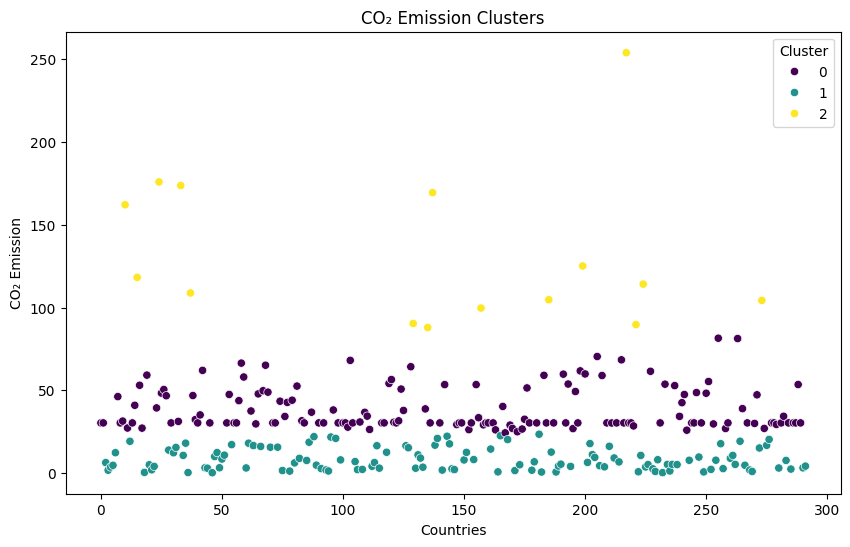

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df.index,
    y='CO2_Emission',
    hue='Cluster',
    data=df,
    palette='viridis'
)

plt.title("CO₂ Emission Clusters")
plt.xlabel("Countries")
plt.ylabel("CO₂ Emission")
plt.show()